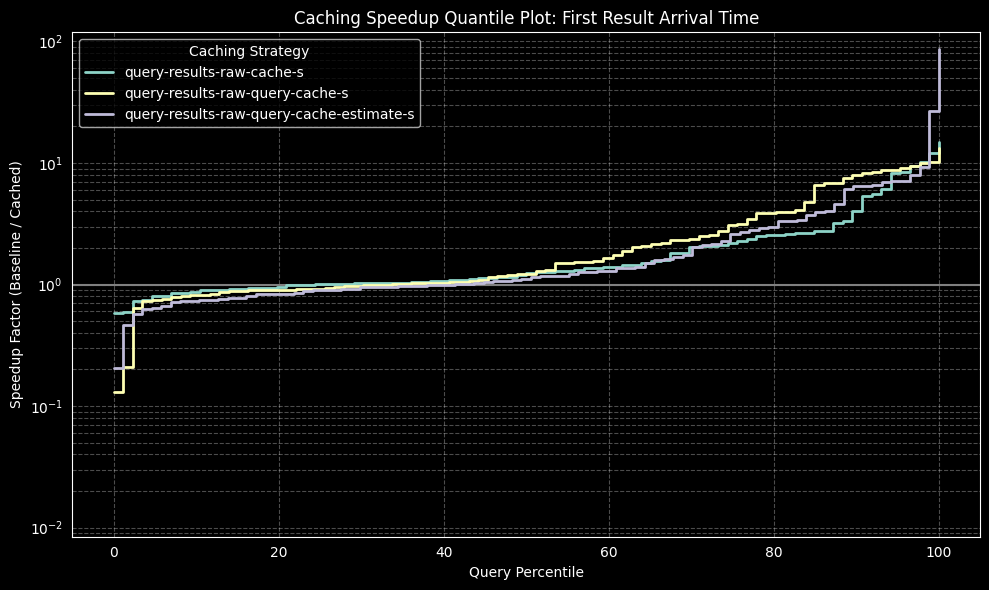

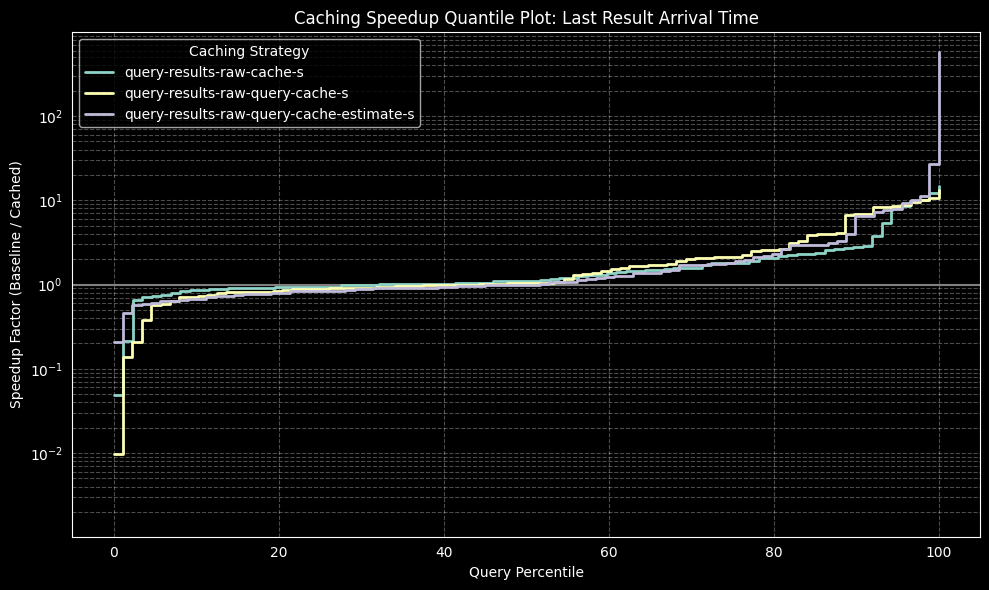

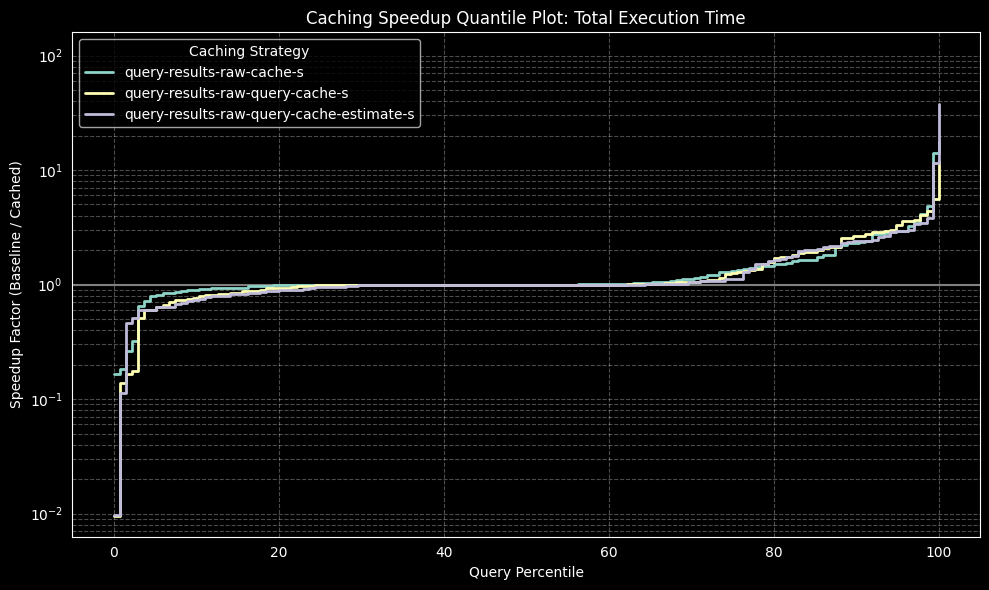

In [3]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_speedup_from_locations(baseline_locations, cache_locations, metric='time', log_scale=True):
    """
    Plots a logarithmic inverted ECDF comparing multiple caching strategies.
    Supports latency and throughput-normalized speedups.
    Latency is calculated time till first result, when BOTH queries have a first result.
    For total time and last timestamp, we calculate the throughput-normalized speedup, which is
    the multiplication of ratio of latency and result volume
    So: Throughput Speedup = (Time_base / Time_cache) * (Results_cache / Results_base)
    This is to measure both faster execution AND the number of results produced by the queries.
    Valid 'metric' options: 'time', 'first_ts', 'last_ts'
    """

    def parse_file(filepath):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                timestamps = item.get('timestamps', [])

                # Extract timestamps safely
                first_ts = timestamps[0] if timestamps else None
                last_ts = timestamps[-1] if timestamps else None
                num_results = len(timestamps)

                records.append({
                    'name': item.get('name'),
                    'id': item.get('id'),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time'),
                    'first_ts': first_ts,
                    'last_ts': last_ts,
                    'num_results': num_results
                })
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc) for loc in baseline_locations]
    df_base = pd.concat(df_base_list, ignore_index=True)

    # Aggregate the 10 repetitions using the median
    df_base_agg = df_base.groupby(['name', 'id', 'template']).agg({
        'time': 'median',
        'first_ts': 'median',
        'last_ts': 'median',
        'num_results': 'median'
    }).reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Process Each Cache Strategy
    for cache_loc in cache_locations:
        strategy_label = os.path.basename(cache_loc).replace('.json', '')

        df_cache = parse_file(cache_loc)
        df_cache_agg = df_cache.groupby(['name', 'id', 'template']).agg({
            'time': 'median',
            'first_ts': 'median',
            'last_ts': 'median',
            'num_results': 'median'
        }).reset_index()

        # Merge with baseline to align exact queries
        merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id', 'template'], suffixes=('_base', '_cache'))

        # Prevent division by zero for queries that naturally return 0 results
        safe_base_results = np.maximum(1, merged['num_results_base'])
        safe_cache_results = np.maximum(1, merged['num_results_cache'])

        # 3. Calculate Speedup based on Metric Type
        if metric == 'first_ts':
            # Pure latency: Evaluate only if BOTH runs produced at least one result
            valid_mask = (merged['num_results_base'] > 0) & (merged['num_results_cache'] > 0)
            merged = merged[valid_mask]
            merged['speedup'] = merged['first_ts_base'] / merged['first_ts_cache']

        elif metric in ['time', 'last_ts']:
            # Throughput-Normalized Speedup: Latency Ratio * Result Volume Ratio
            latency_ratio = merged[f'{metric}_base'] / merged[f'{metric}_cache']
            result_ratio = safe_cache_results / safe_base_results
            merged['speedup'] = latency_ratio * result_ratio

        else:
            raise ValueError("Invalid metric. Choose 'time', 'first_ts', or 'last_ts'.")

        # Extract values, filter invalid log inputs, and sort for ECDF
        speedups = merged['speedup'].dropna().values
        speedups = speedups[speedups > 0]
        speedups.sort()

        # Generate percentiles and plot step function
        percentiles = np.linspace(0, 100, len(speedups))
        ax.step(percentiles, speedups, where='post', linewidth=2, label=strategy_label)

    # 4. Apply Graph Formatting
    ax.axhline(1.0, color='gray', linestyle='-', linewidth=1.5, zorder=1)

    if log_scale:
        ax.set_yscale('log')
        ymin, ymax = ax.get_ylim()

        # Symmetrically center the Y-axis around 1 (10^0)
        if ymin > 0 and ymax > 0:
            max_log_dev = max(abs(np.log10(ymin)), abs(np.log10(ymax)))
            ax.set_ylim(10 ** (-max_log_dev), 10 ** max_log_dev)

    # Map internal metric names to clean chart titles
    metric_labels = {
        'time': 'Total Execution Time',
        'first_ts': 'First Result Arrival Time',
        'last_ts': 'Last Result Arrival Time'
    }
    display_metric = metric_labels.get(metric, metric)

    ax.set_xlabel('Query Percentile')
    ax.set_ylabel('Speedup Factor (Baseline / Cached)')
    ax.set_title(f'Caching Speedup Quantile Plot: {display_metric}')

    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(title="Caching Strategy")

    plt.tight_layout()
    plt.show()

raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")

all_locations_cache = [raw_data_cache_s, raw_data_query_cache_s, raw_data_query_cache_estimate_s]
location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

# uncached_files = ["/path/to/baseline_run1.json", "/path/to/baseline_run2.json"]
# cached_files = ["/path/to/cached_run1.json", "/path/to/cached_run2.json"]
# plot_speedup_from_locations(location_default, all_locations_cache, log_scale=False)
plot_speedup_from_locations(location_default, all_locations_cache, log_scale=True, metric="first_ts")
plot_speedup_from_locations(location_default, all_locations_cache, log_scale=True, metric="last_ts")
plot_speedup_from_locations(location_default, all_locations_cache, log_scale=True, metric="time")

